# Clasificación de gestos de mano mediante señales EMG utilizando redes LSTM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
import glob
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import mean_absolute_error
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

Mounted at /content/drive


In [ ]:
baseDir = "/content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG"

datasetPath = os.path.join(baseDir, "Dataset")
modelsDir   = os.path.join(baseDir, "Models", "Train models")
scalersDir  = os.path.join(baseDir, "Scalers")

modelPath  = os.path.join(modelsDir, "EMGCNNLSTMModel2.pt")
scalerPath = os.path.join(scalersDir, "scaler.save")

trainingCurvesPath = os.path.join(baseDir, "training_curves2.npz")

print("datasetPath:", datasetPath)
print("modelPath:", modelPath)
print("scalerPath:", scalerPath)
print("trainingCurvesPath:", trainingCurvesPath)

datasetPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Dataset
modelPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Models/Train models/EMGCNNLSTMModel2.pt
scalerPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Scalers/scaler.save
trainingCurvesPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/training_curves2.npz


In [ ]:
txtFiles = sorted(glob.glob(os.path.join(datasetPath, "**/*.txt"), recursive=True))
print(f"Archivos encontrados: {len(txtFiles)}")

Archivos encontrados: 82


In [ ]:
def loadFile(filePath):
    try:
        dfRaw = pd.read_csv(
            filePath,
            sep=r"\s+",
            engine="python",
            header=None,
            on_bad_lines='skip'
        )

        if dfRaw.shape[1] != 10:
            print(f"Archivo con columnas inesperadas: {filePath} : {dfRaw.shape[1]} columnas")
            return pd.DataFrame()

        dfRaw.columns = ['time'] + [f'ch{i}' for i in range(1, 9)] + ['label']
        dfRaw = dfRaw[dfRaw['label'] != 0]
        return dfRaw

    except Exception as e:
        print(f"Error al leer {filePath}: {e}")
        return pd.DataFrame()


allDataDf = pd.concat([loadFile(f) for f in txtFiles], ignore_index=True)
print(allDataDf.head())
print(allDataDf['label'].value_counts())

Archivo con columnas inesperadas: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Dataset/README.txt : 3 columnas
   time       ch1       ch2       ch3       ch4       ch5       ch6       ch7  \
0  time  channel1  channel2  channel3  channel4  channel5  channel6  channel7   
1     1     1e-05    -2e-05    -1e-05    -3e-05         0    -1e-05         0   
2     5     1e-05    -2e-05    -1e-05    -3e-05         0    -1e-05         0   
3     6    -1e-05     1e-05     2e-05         0     1e-05    -2e-05    -1e-05   
4     7    -1e-05     1e-05     2e-05         0     1e-05    -2e-05    -1e-05   

        ch8  label  
0  channel8  class  
1    -1e-05      0  
2    -1e-05      0  
3     1e-05      0  
4     1e-05      0  
label
0        3083237
6         282646
5         282008
1         280847
4         280543
3         279131
2         272798
7          17125
class         81
Name: count, dtype: int64


In [ ]:
allDataDf = allDataDf.apply(pd.to_numeric, errors='coerce')
allDataDf = allDataDf.dropna().reset_index(drop=True)

print("Shape después de limpiar filas no numéricas:", allDataDf.shape)

Shape después de limpiar filas no numéricas: (4778335, 10)


In [ ]:
dfChannels = [f'ch{i}' for i in range(1, 9)]

scaler = StandardScaler()
allDataDf[dfChannels] = scaler.fit_transform(allDataDf[dfChannels])

print(allDataDf[dfChannels].describe().T[['mean', 'std']])

             mean  std
ch1 -3.574770e-17  1.0
ch2  6.548416e-17  1.0
ch3  5.701193e-17  1.0
ch4 -1.475931e-17  1.0
ch5 -2.667992e-17  1.0
ch6 -2.399884e-17  1.0
ch7 -9.445481e-18  1.0
ch8 -3.703991e-17  1.0


In [ ]:
def createSlidingWindows(dataframe, channels, windowSize=200, stepSize=100):
    x, y = [], []
    dataArray = dataframe[channels + ['label']].values
    totalLen = len(dataArray)

    for start in range(0, totalLen - windowSize, stepSize):
        end = start + windowSize
        window = dataArray[start:end]
        segment = window[:, :-1]
        labels = window[:, -1]

        if np.all(labels == labels[0]):
            x.append(segment)
            y.append(int(labels[0]))

    return np.array(x), np.array(y)

In [ ]:
windowSize = 200
stepSize = 100

xData, yData = createSlidingWindows(allDataDf, dfChannels, windowSize, stepSize)

print("X shape:", xData.shape)
print("y shape:", yData.shape)
print("Clases disponibles:", np.unique(yData, return_counts=True))

X shape: (43878, 200, 8)
y shape: (43878,)
Clases disponibles: (array([0, 1, 2, 3, 4, 5, 6, 7]), array([28869,  2490,  2405,  2473,  2486,  2492,  2511,   152]))


In [ ]:
# Train (80%) y test/val (20%)
xTrain, xTestVal, yTrain, yTestVal = train_test_split(
    xData, yData, test_size=0.2, stratify=yData, random_state=42
)

# De test/val (20%), sacamos val (10%) y test (10%)
xVal, xTest, yVal, yTest = train_test_split(
    xTestVal, yTestVal, test_size=0.5, stratify=yTestVal, random_state=42
)

print("Train:", xTrain.shape, yTrain.shape)
print("Val:", xVal.shape, yVal.shape)
print("Test:", xTest.shape, yTest.shape)

Train: (35102, 200, 8) (35102,)
Val: (4388, 200, 8) (4388,)
Test: (4388, 200, 8) (4388,)


In [ ]:
class EMGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
batchSize = 64

dfTrain = EMGDataset(xTrain, yTrain)
dfVal   = EMGDataset(xVal, yVal)
dfTest  = EMGDataset(xTest, yTest)

loaderTrain = DataLoader(dfTrain, batch_size=batchSize, shuffle=True)
loaderVal  = DataLoader(dfVal, batch_size=batchSize, shuffle=False)
loaderTest  = DataLoader(dfTest, batch_size=batchSize, shuffle=False)

In [ ]:
class EMGCNNLSTMClassifier(nn.Module):
    def __init__(self, in_channels=8, num_classes=8):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)         # (B, C, T')
        x = x.permute(0, 2, 1)  # (B, T', C)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

model = EMGCNNLSTMClassifier().to(device)

Usando dispositivo: cuda


In [ ]:
epochs = 30
learningRate = 0.01

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learningRate)

def evaluate(model, dataLoader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for xBatch, yBatch in dataLoader:
            xBatch, yBatch = xBatch.to(device), yBatch.to(device)
            outputs = model(xBatch)
            _, predicted = torch.max(outputs.data, 1)
            total += yBatch.size(0)
            correct += (predicted == yBatch).sum().item()

    return 100 * correct / total

In [ ]:
lossesTrain = []
accuraciesVal = []

for epoch in range(epochs):
    model.train()
    runningLoss = 0.0
    progressBar = tqdm(loaderTrain, desc=f"Época {epoch+1}/{epochs}")

    for xBatch, yBatch in progressBar:
        xBatch, yBatch = xBatch.to(device), yBatch.to(device)
        optimizer.zero_grad()
        outputs = model(xBatch)
        loss = criterion(outputs, yBatch)
        loss.backward()
        optimizer.step()
        runningLoss += loss.item()
        progressBar.set_postfix(loss=loss.item())

    avg_loss = runningLoss / len(loaderTrain)
    val_acc = evaluate(model, loaderVal)
    lossesTrain.append(avg_loss)
    accuraciesVal.append(val_acc)

    print(f"=> Época {epoch+1}: Loss={avg_loss:.4f} | Val Acc={val_acc:.2f}%")

Época 1/30: 100%|██████████| 549/549 [00:43<00:00, 12.49it/s, loss=0.819]


=> Época 1: Loss=1.0486 | Val Acc=65.79%


Época 2/30: 100%|██████████| 549/549 [00:40<00:00, 13.63it/s, loss=1.09]


=> Época 2: Loss=0.9406 | Val Acc=65.91%


Época 3/30: 100%|██████████| 549/549 [00:39<00:00, 14.06it/s, loss=0.772]


...

=> Época 28: Loss=0.7035 | Val Acc=67.59%


Época 29/30: 100%|██████████| 549/549 [00:34<00:00, 15.87it/s, loss=0.736]


=> Época 29: Loss=0.7082 | Val Acc=68.78%


Época 30/30: 100%|██████████| 549/549 [00:38<00:00, 14.37it/s, loss=0.708]


=> Época 30: Loss=0.7008 | Val Acc=69.23%


In [ ]:
def getAllPreds(model, dataLoader):
    model.eval()
    yTrue, yPred = [], []

    with torch.no_grad():
        for xBatch, yBatch in dataLoader:
            xBatch = xBatch.to(device)
            outputs = model(xBatch)
            _, predicted = torch.max(outputs.data, 1)

            yTrue.extend(yBatch.cpu().numpy())
            yPred.extend(predicted.cpu().numpy())

    return np.array(yTrue), np.array(yPred)

yTrueTest, yPredTest = getAllPreds(model, loaderTest)

accuracyTest = np.mean(yTrueTest == yPredTest) * 100

maeTest = mean_absolute_error(yTrueTest, yPredTest)
biasTest = np.mean(yPredTest - yTrueTest)
varTest = np.var(yPredTest)

print(f"Accuracy en test set: {accuracyTest:.2f}%")
print(f"MAE (Test): {maeTest:.4f}")
print(f"Bias (Test): {biasTest:.4f}")
print(f"Varianza (Test): {varTest:.4f}")

Accuracy en test set: 68.41%
MAE (Test): 1.0980
Bias (Test): -0.6472
Varianza (Test): 2.2515


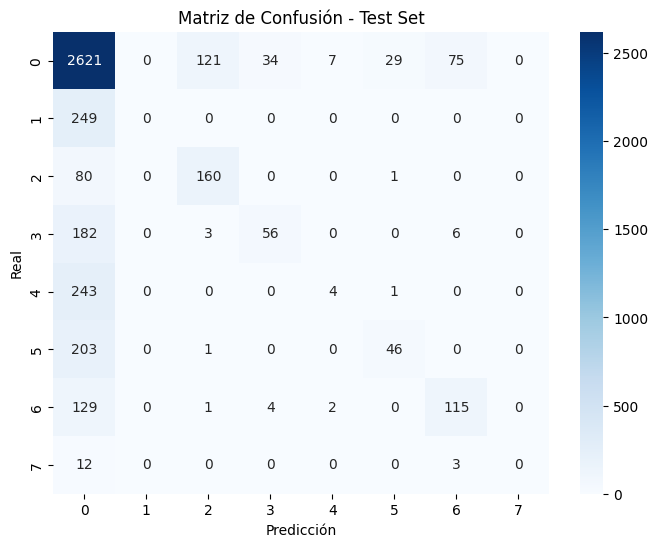

In [ ]:
cm = confusion_matrix(yTrueTest, yPredTest)
labels = np.unique(yData)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Test Set')
plt.show()

In [ ]:
print("Reporte de clasificación:")
print(classification_report(yTrueTest, yPredTest, digits=4))

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.7048    0.9079    0.7935      2887
           1     0.0000    0.0000    0.0000       249
           2     0.5594    0.6639    0.6072       241
           3     0.5957    0.2267    0.3284       247
           4     0.3077    0.0161    0.0307       248
           5     0.5974    0.1840    0.2813       250
           6     0.5779    0.4582    0.5111       251
           7     0.0000    0.0000    0.0000        15

    accuracy                         0.6841      4388
   macro avg     0.4179    0.3071    0.3190      4388
weighted avg     0.6124    0.6841    0.6209      4388



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
torch.save(model.state_dict(), modelPath)
joblib.dump(scaler, scalerPath)
np.savez(trainingCurvesPath,
         lossesTrain=np.array(lossesTrain),
         accuraciesVal=np.array(accuraciesVal),
         accuracyTest=np.array([accuracyTest]),
         maeTest=np.array([maeTest]),
         biasTest=np.array([biasTest]),
         varTest=np.array([varTest]))

print("Modelo guardado en:", modelPath)
print("Scaler guardado en:", scalerPath)
print("Curvas de entrenamiento guardadas en training_curves2.npz")

Modelo guardado en: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Models/Train models/EMGCNNLSTMModel2.pt
Scaler guardado en: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Scalers/scaler.save
Curvas de entrenamiento guardadas en training_curves2.npz


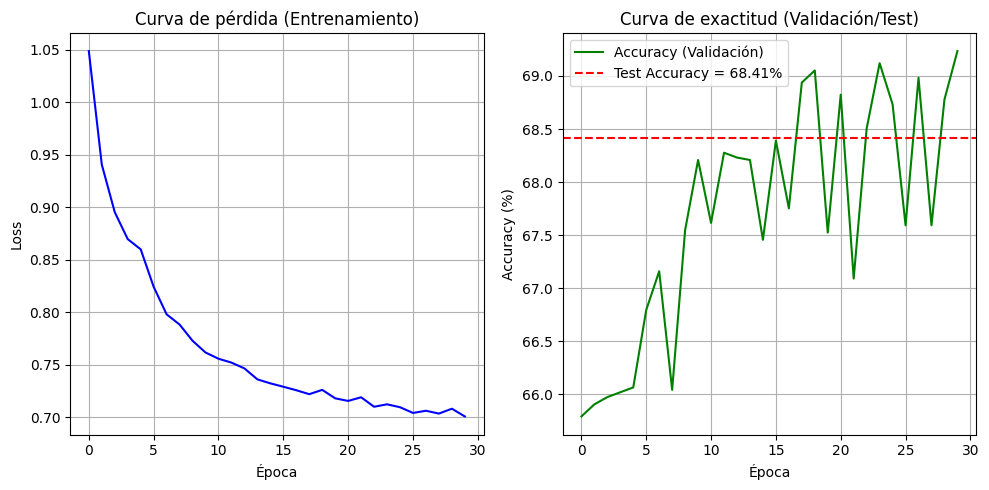

In [ ]:
data = np.load(trainingCurvesPath, allow_pickle=True)
lossesTrain = data["lossesTrain"]
accuraciesVal = data["accuraciesVal"]
accuracyTest = data["accuracyTest"][0]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(lossesTrain, label="Loss (Train)", color="blue")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida (Entrenamiento)")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(accuraciesVal, label="Accuracy (Validación)", color="green")
plt.axhline(y=accuracyTest, color="red", linestyle="--",
            label=f"Test Accuracy = {accuracyTest:.2f}%")
plt.xlabel("Época")
plt.ylabel("Accuracy (%)")
plt.title("Curva de exactitud (Validación/Test)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()